# Importar Librerías

In [4]:
# CARGAR API FastF1
from IPython.display import clear_output
# https://docs.fastf1.dev/
!pip install fastf1
clear_output()

In [ ]:
# import fastf1

# schedule = fastf1.get_event_schedule(2025)
# print(schedule[["EventName"]])

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

# Carga de Datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/My Drive/Data-IIC2613/

/content/drive/My Drive/Data-IIC2613


In [5]:
df = pd.read_csv("races.csv")
df.head()

,Year,GrandPrix,Race_BestLap,Race_NumLaps,Practice_2_BestLap,Practice_2_NumLaps,Practice_1_BestLap,Practice_1_NumLaps,Practice_3_BestLap,Practice_3_NumLaps,...,Qualifying_NumLaps,Race_GridPosition,Race_Position,Race_Status,Race_Points,Race_BestLapTime,Race_NumberOfPitStops,Driver_ID,Driver_Abbrev,Driver_FullName
0,2023,Bahrain Grand Prix,96.236,57.0,91.076,24.0,93.375,21.0,92.345,13.0,...,15.0,1.0,1.0,Finished,25.0,0 days 01:33:56.736000,2.0,1,VER,Max Verstappen
1,2023,Bahrain Grand Prix,96.037,56.0,92.749,29.0,95.749,24.0,93.665,15.0,...,6.0,16.0,12.0,Lapped,0.0,0 days 00:00:01.136000,3.0,2,SAR,Logan Sargeant
2,2023,Bahrain Grand Prix,95.257,55.0,91.570,27.0,94.165,21.0,93.202,16.0,...,13.0,11.0,17.0,Lapped,0.0,0 days 00:00:06.636000,6.0,4,NOR,Lando Norris
3,2023,Bahrain Grand Prix,95.068,57.0,91.475,24.0,95.455,22.0,93.064,13.0,...,6.0,20.0,9.0,Finished,2.0,0 days 00:01:13.753000,3.0,10,GAS,Pierre Gasly
4,2023,Bahrain Grand Prix,96.344,57.0,91.078,26.0,92.758,21.0,92.446,12.0,...,15.0,2.0,2.0,Finished,18.0,0 days 00:00:11.987000,2.0,11,PER,Sergio Perez


# Estudio de Datos

In [6]:
# @title
# ¿Cúantos datos hay?

print("Cantidad de datos: " + str(len(df)))
# ¿Cúantos atributos hay y cúales son?

print("Atributos: " + str(list(df.columns)))

for col in df.columns:
  print(col + ": " + str(df[col].dtype))
# ¿Cúal es la columna que queremos predecir

print("Columna a Predecir: "  + str(df.columns[-8]))


Cantidad de datos: 1559
Atributos: ['Year', 'GrandPrix', 'Race_BestLap', 'Race_NumLaps', 'Practice_2_BestLap', 'Practice_2_NumLaps', 'Practice_1_BestLap', 'Practice_1_NumLaps', 'Practice_3_BestLap', 'Practice_3_NumLaps', 'Qualifying_BestLap', 'Qualifying_NumLaps', 'Race_GridPosition', 'Race_Position', 'Race_Status', 'Race_Points', 'Race_BestLapTime', 'Race_NumberOfPitStops', 'Driver_ID', 'Driver_Abbrev', 'Driver_FullName']
Year: int64
GrandPrix: object
Race_BestLap: float64
Race_NumLaps: float64
Practice_2_BestLap: float64
Practice_2_NumLaps: float64
Practice_1_BestLap: float64
Practice_1_NumLaps: float64
Practice_3_BestLap: float64
Practice_3_NumLaps: float64
Qualifying_BestLap: float64
Qualifying_NumLaps: float64
Race_GridPosition: float64
Race_Position: float64
Race_Status: object
Race_Points: float64
Race_BestLapTime: object
Race_NumberOfPitStops: float64
Driver_ID: int64
Driver_Abbrev: object
Driver_FullName: object
Columna a Predecir: Race_Position


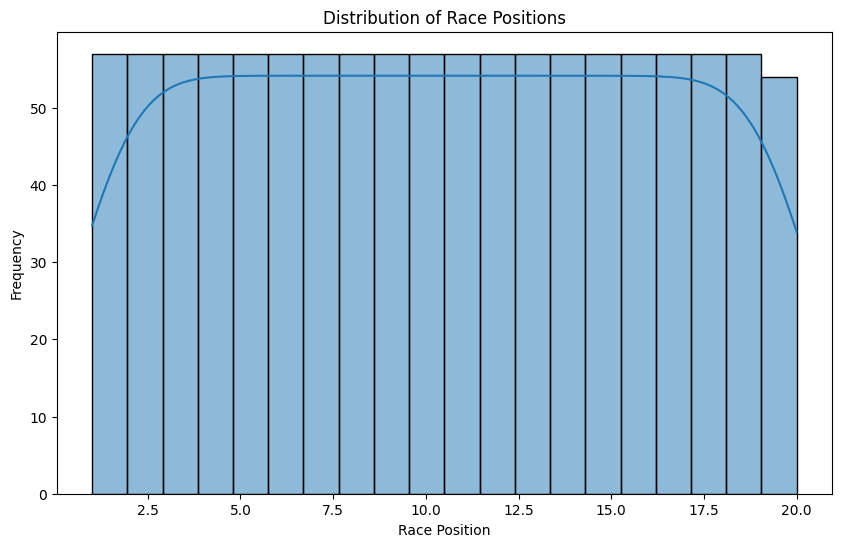

In [13]:
# Distribución Grafica

# ¿Cómo se ve la distribución de las posiciones finales en las carreras?
plt.figure(figsize=(10, 6))
sns.histplot(x='Race_Position', data=df, bins=20, kde=True) # Using a histogram instead of countplot
plt.title('Distribution of Race Positions')
plt.xlabel('Race Position')
plt.ylabel('Frequency')
plt.show()

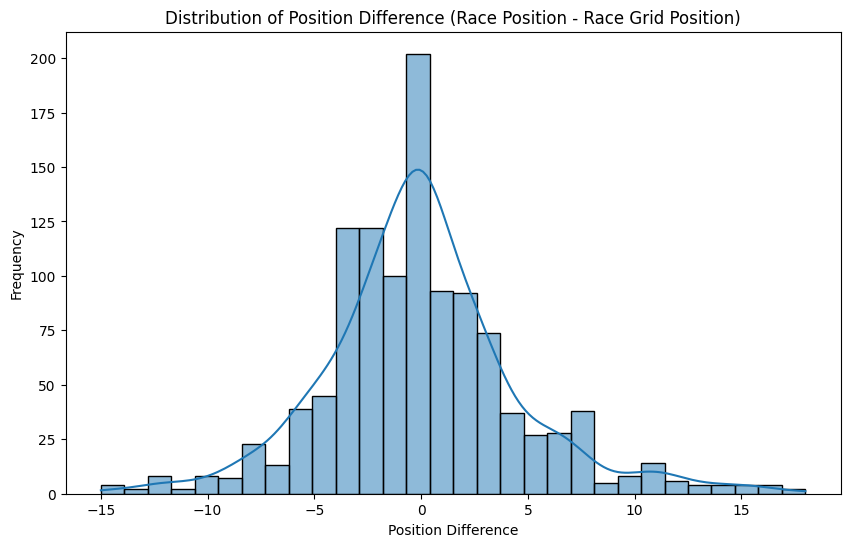

In [15]:
# Calcular la diferencia entre la posición de la parrilla y la posición final
df['Position_Difference'] = df['Race_Position'] - df['Race_GridPosition']

# Visualizar la distribución de la diferencia de posición
plt.figure(figsize=(10, 6))
sns.histplot(x='Position_Difference', data=df, bins=30, kde=True)
plt.title('Distribution of Position Difference (Race Position - Race Grid Position)')
plt.xlabel('Position Difference')
plt.ylabel('Frequency')
plt.show()

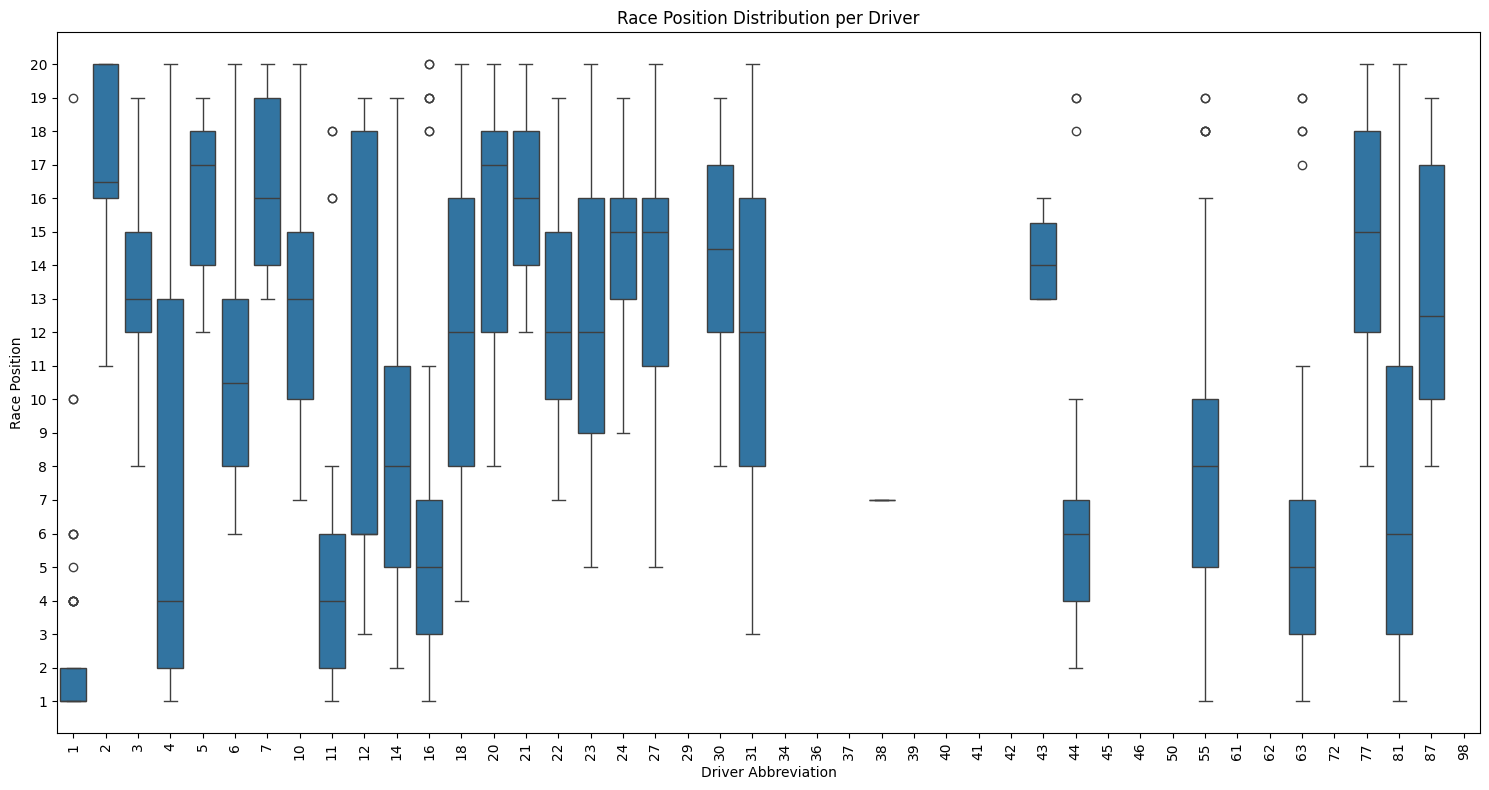

In [25]:
# Rendimiento de los pilotos a lo largo de las temporadas
plt.figure(figsize=(15, 8))
sns.boxplot(x='Driver_ID', y='Race_Position', data=df)
plt.title('Race Position Distribution per Driver')
plt.xlabel('Driver Abbreviation')
plt.ylabel('Race Position')
plt.xticks(rotation=90)
plt.yticks(np.arange(df['Race_Position'].min(), df['Race_Position'].max() + 1, 1)) # Set y-ticks to show integers with step 2
plt.gca().yaxis.get_major_formatter().set_scientific(False) # Prevent scientific notation
plt.tight_layout()
plt.show()

# División de Datos

In [125]:
X = df.drop('Race_Position', axis=1)
y = df['Race_Position']

X_train = X[(X['Year'] == 2023) | (X['Year'] == 2024)]
y_train = y[(X['Year'] == 2023) | (X['Year'] == 2024)]
X_test = X[X['Year'] == 2025]
y_test = y[X['Year'] == 2025]


print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (1350, 20)
Shape de X_test: (209, 20)
Shape de y_train: (1350,)
Shape de y_test: (209,)


# Preprocesamiento de Datos

In [126]:
# @title Valores nulos de los datos iniciales
# Datos nulos iniciales
print(df.isnull().sum())

Year                       0
GrandPrix                  0
Race_BestLap             540
Race_NumLaps             522
Practice_2_BestLap       458
Practice_2_NumLaps       457
Practice_1_BestLap        89
Practice_1_NumLaps        69
Practice_3_BestLap       486
Practice_3_NumLaps       484
Qualifying_BestLap       544
Qualifying_NumLaps       540
Race_GridPosition        422
Race_Position            422
Race_Status              422
Race_Points              422
Race_BestLapTime         559
Race_NumberOfPitStops    522
Driver_ID                  0
Driver_Abbrev              0
Driver_FullName            0
dtype: int64


In [127]:
indices_validos = y_train.notnull()

y_train = y_train[indices_validos]
X_train = X_train[indices_validos]

indices_validos_test = y_test.notnull()
y_test = y_test[indices_validos_test]
X_test = X_test[indices_validos_test]

print("Shape de X_train:", X_train.shape)
print("Shape de y_train:", y_train.shape)

Shape de X_train: (938, 20)
Shape de y_train: (938,)


In [128]:
# Columnas a eliminar (Data leakage)
cols_to_drop = [
    'Race_BestLap', 'Race_NumLaps', 'Race_Status', 'Race_Points',
    'Race_BestLapTime', 'Race_NumberOfPitStops', 'Practice_2_BestLap',
    'Practice_3_BestLap', 'Qualifying_BestLap', 'Practice_2_NumLaps',
    'Practice_3_NumLaps', 'Qualifying_NumLaps'
]

# Columnas de texto redundantes
cols_text_drop = ['Driver_Abbrev', 'Driver_FullName']

# Columnas a rellenar con 0
cols_to_fill_zero = ['Practice_1_BestLap', 'Practice_1_NumLaps']

grid_position_imputer = X_train['Race_GridPosition'].mean()

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_train = X_train.drop(columns=cols_text_drop, errors='ignore')
X_train[cols_to_fill_zero] = X_train[cols_to_fill_zero].fillna(0)
X_train['Race_GridPosition'] = X_train['Race_GridPosition'].fillna(grid_position_imputer)


X_test = X_test.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_text_drop, errors='ignore')
X_test[cols_to_fill_zero] = X_test[cols_to_fill_zero].fillna(0)
X_test['Race_GridPosition'] = X_test['Race_GridPosition'].fillna(grid_position_imputer)
X_test = X_test.fillna(0)

print("Limpieza de X_test completada.")

# One-Hot Encoding -> Pasar los datos STR del GrandPrix a columnas
X_train = pd.get_dummies(X_train, columns=['GrandPrix'])
X_test = pd.get_dummies(X_test, columns=['GrandPrix'])

# Se alinea para que ambos tengan las mismas columnas del GrandPrix
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


print(f"Nulos restantes en X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos restantes en X_test:  {X_test.isnull().sum().sum()}")
print(f"Shape final de X_train: {X_train.shape}")
print(f"Shape final de X_test:  {X_test.shape}")

Limpieza de X_test completada.
Nulos restantes en X_train: 0
Nulos restantes en X_test:  0
Shape final de X_train: (938, 21)
Shape final de X_test:  (199, 21)


In [129]:
print(X_train.isnull().sum())


Year                                   0
Practice_1_BestLap                     0
Practice_1_NumLaps                     0
Race_GridPosition                      0
Driver_ID                              0
GrandPrix_Abu Dhabi Grand Prix         0
GrandPrix_Australian Grand Prix        0
GrandPrix_Austrian Grand Prix          0
GrandPrix_Azerbaijan Grand Prix        0
GrandPrix_Bahrain Grand Prix           0
GrandPrix_British Grand Prix           0
GrandPrix_Canadian Grand Prix          0
GrandPrix_Chinese Grand Prix           0
GrandPrix_Emilia Romagna Grand Prix    0
GrandPrix_Hungarian Grand Prix         0
GrandPrix_Japanese Grand Prix          0
GrandPrix_Las Vegas Grand Prix         0
GrandPrix_Miami Grand Prix             0
GrandPrix_Monaco Grand Prix            0
GrandPrix_Saudi Arabian Grand Prix     0
GrandPrix_Spanish Grand Prix           0
dtype: int64


# Entrenamiento de Modelos

In [130]:
from sklearn.linear_model import LinearRegression

modelo_lineal = LinearRegression()

print("Entrenando el modelo de Regresión Lineal...")
modelo_lineal.fit(X_train, y_train)
print("¡Modelo entrenado!")


y_pred_lineal_test = modelo_lineal.predict(X_test)
y_pred_lineal_train = modelo_lineal.predict(X_train)

print("\nPrimeras 5 predicciones (test):", y_pred_lineal_test[:5])
print("Primeros 5 valores reales (test):", y_test.values[:5])

Entrenando el modelo de Regresión Lineal...
¡Modelo entrenado!

Primeras 5 predicciones (test): [ 5.57161884  4.69759148 11.58590345  9.49662532  8.784075  ]
Primeros 5 valores reales (test): [10.  2. 12.  7.  8.]


In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, y_pred_lineal_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lineal_test))
r2 = r2_score(y_test, y_pred_lineal_test)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

--- Evaluación del Modelo de Regresión Lineal (Test Set) ---
Mean Absolute Error (MAE): 3.2155
Root Mean Squared Error (RMSE): 4.1390
R^2 Score: 0.4803


In [132]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_leaf': [2, 5]
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

y_pred_rf_test = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
r2_rf = r2_score(y_test, y_pred_rf_test)

print("\n--- Evaluación del Modelo RandomForest (Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R^2 Score: {r2_rf:.4f}")

Iniciando GridSearchCV para RandomForest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
¡GridSearchCV completado!

Mejores hiperparámetros encontrados:
{'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 100}

--- Evaluación del Modelo RandomForest (Test Set) ---
Mean Absolute Error (MAE): 1.6833
Root Mean Squared Error (RMSE): 2.2594
R^2 Score: 0.8451


# Análisis de Resultados

| Métrica | Modelo 1 (Regresión Lineal) | Modelo 2 (Random Forest) |
| :--- | :---: | :---: |
| **MAE** (Error Absoluto Medio) | 3.2155 | **1.6833** |
| **RMSE** (Raíz del Error Cuadrático Medio) | 4.1390 | **2.2594** |
| **R² Score** (Coeficiente de Determinación) | 0.4803 (48.0%) | **0.8451 (84.5%)** |
```

In [133]:
from scipy.stats import spearmanr

# Calcular la correlación de Spearman
correlation, p_value = spearmanr(y_test, y_pred_rf_test)

print(f"Correlación de Rango de Spearman: {correlation:.4f}")

Correlación de Rango de Spearman: 0.9292


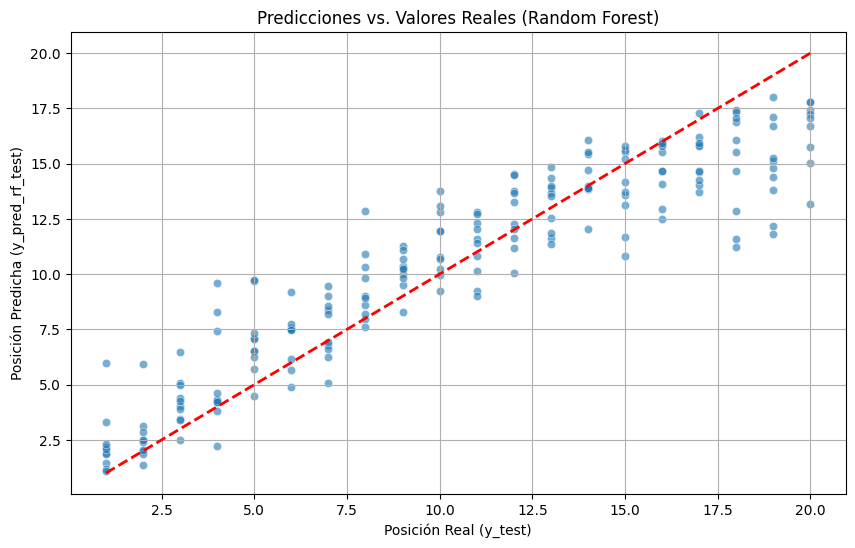

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns


# --- Gráfico 1: Predicciones vs. Valores Reales ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_test, alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)

plt.title('Predicciones vs. Valores Reales (Random Forest)')
plt.xlabel('Posición Real (y_test)')
plt.ylabel('Posición Predicha (y_pred_rf_test)')
plt.grid(True)
plt.show()

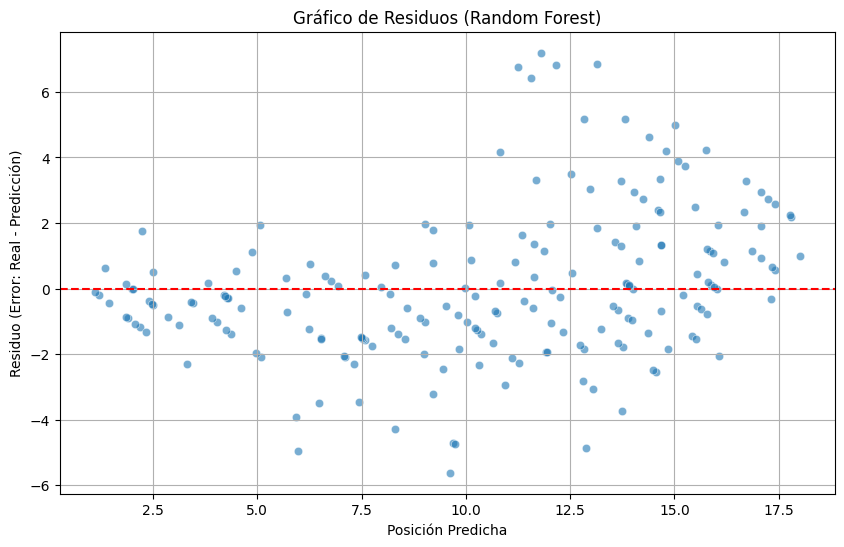

In [136]:
residuos = y_test - y_pred_rf_test

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf_test, y=residuos, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Gráfico de Residuos (Random Forest)')
plt.xlabel('Posición Predicha')
plt.ylabel('Residuo (Error: Real - Predicción)')
plt.grid(True)
plt.show()

# Bonus

## Enriquecimiento de Datos

La API FastF1 contiene muchos enpoints, con una gran cantidad de datos describiendo a detalle cada sesión. Investiga en la documentación y extrae información que consideres relevante. Con estos nuevos datos entrena un nuevo modelo y análisa sus resultados.

In [ ]:
# RECUERDA IMPORTAR LAS LIBRERÍAS

## Bonus: GP BRASIL

In [ ]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def extract_session_data(year, gp_name, session_type):
    """Descarga una sesión específica (P1, P2, P3, Q, S, R)"""
    try:
        session = fastf1.get_session(year, gp_name, session_type)
        session.load(laps=True, telemetry=True, weather=True, messages=False)
        folder = f"data/{year}_{gp_name}/{session.name}"
        ensure_dir(folder)
        # Guardar resultados generales
        session.results.to_csv(f"{folder}/results.csv", index=False)
        print(f"✅ {year} - {gp_name} - {session.name} completado")
        return True

    except Exception as e:
        print(f"❌ Error en {year} - {gp_name} - {session_type}: {e}")
        return False

In [ ]:
year = 2025
gp_name = "São Paulo Grand Prix"
for session_type in ["FP1", "FP2", "FP3", "Qualifying"]: # OJO: En esta carrera no hay 3 sesiones de práctica, así que estos datos saldrán nulos
    extract_session_data(year, gp_name, session_type)